In [1]:
# import draw_dot
# draw_dot.draw_dot(o)

# OR
%run draw_dot.py
# draw_dot(o)

In [32]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [115]:
class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        """ this is to render result instead of cryptic output in Python """
        return f"Value(data={self.data})"

    def __add__(self, operand):
        operand = operand if isinstance(operand, Value) else Value(operand)
        
        out = Value(self.data + operand.data, (self, operand), '+')

        """ plus-op just copies grad result """
        def _backward():
            self.grad += 1.0 * out.grad
            operand.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out

    def __mul__(self, operand):
        operand = operand if isinstance(operand, Value) else Value(operand)
        
        out = Value(self.data * operand.data, (self, operand), '*')

        def _backward():
            self.grad += operand.data * out.grad
            operand.grad += self.data * out.grad
        out._backward = _backward
        
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad = (1 - out.data ** 2) * out.grad
        out._backward = _backward
        
        return out

    def backward(self):
        topo = []
        
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    def __radd__(self, other): # other + self
        return self + other
    def __rmul__(self, other): # other * self
        return self * other

    def __neg__(self): # -self
        return self * -1
    def __sub__(self, other): # self - other
        return self + (-other)

    def __pow__(self, other):
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
            out._backward = _backward
        return out

    def __truediv__(self, other): # self / other
        return self * other**-1

    # def exp(self): # to toy with tanH substitute
    #     x = self.data
    #     out = Value(math.exp(x), (self, ), 'exp')

    #     def _backward():
    #         self.grad += out.data * out.grad
    #         out._backward = _backward

    #     return out


In [116]:
import random

class Neuron:
    def __init__(self, number_of_inputs_for_a_neuron):
        self.weights = [Value(random.uniform(-1,1), label='w') for _ in range(number_of_inputs_for_a_neuron)]
        self.bias = Value(random.uniform(-1,1), label='b')

    def __call__(self, x):
        # w + x + b
        neuron_body = sum(
            wi * xi for wi, xi in zip(self.weights, x) 
        ) + self.bias
        return neuron_body.tanh()

class Layer:
    def __init__(self, number_of_inputs_for_a_neuron, number_of_layer_neuron_outputs):
        self.neurons = [Neuron(number_of_inputs_for_a_neuron) for _ in range(number_of_layer_neuron_outputs)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]

        return out[0] if len(out) == 1 else out

class MultiLayerPerceptron:
    def __init__(self, number_of_inputs_for_a_neuron, list_of_numbers_of_layer_neuron_outputs):
        sz = [number_of_inputs_for_a_neuron] + list_of_numbers_of_layer_neuron_outputs
        self.layers = [
            Layer(sz[i], sz[i+1]) for i in range(len(list_of_numbers_of_layer_neuron_outputs))
        ]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

list_of_signals_x = [2.0, 3.0, -1.0]

# refer pic above. we build perceptron for hidden and output layers, and call in with a list of signals fron the input layer
# input_layer_size = 3 # og list_of_signals_x.length
# hidden_layer_1_size = 4
# hidden_layer_2_size = 4
# output_layer_size = 1
mlp = MultiLayerPerceptron(3, [4, 4, 1])
mlp(list_of_signals_x)



Value(data=-0.7232375387258277)

# Tuning

In order to get desired results we need to identify the loss of Neural Net(or how well it performs)


In [117]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] # desired targets

ypred = [mlp(x) for x in xs]
ypred

[Value(data=-0.7232375387258277),
 Value(data=-0.7198458635833968),
 Value(data=-0.29946853961544384),
 Value(data=-0.7272397363481378)]

In [118]:
    # ^2 is purely to get positive num. abs-value can be also used here
    # (yout - y_grad_truth)**2 is a loss func for every resultt, ideally we want it as close to 0 as possible
losses = [(yout - y_grad_truth)**2 for y_grad_truth, yout in zip(ys, ypred)]
losses

[Value(data=2.969547614873848),
 Value(data=0.07848634015133274),
 Value(data=0.490744326988519),
 Value(data=2.9833571068199847)]

In [119]:
total_loss = sum(losses)

total_loss

Value(data=6.522135388833685)

In [120]:
total_loss.backward()

In [121]:
mlp.layers[0].neurons[0].weights[0].grad

0.0

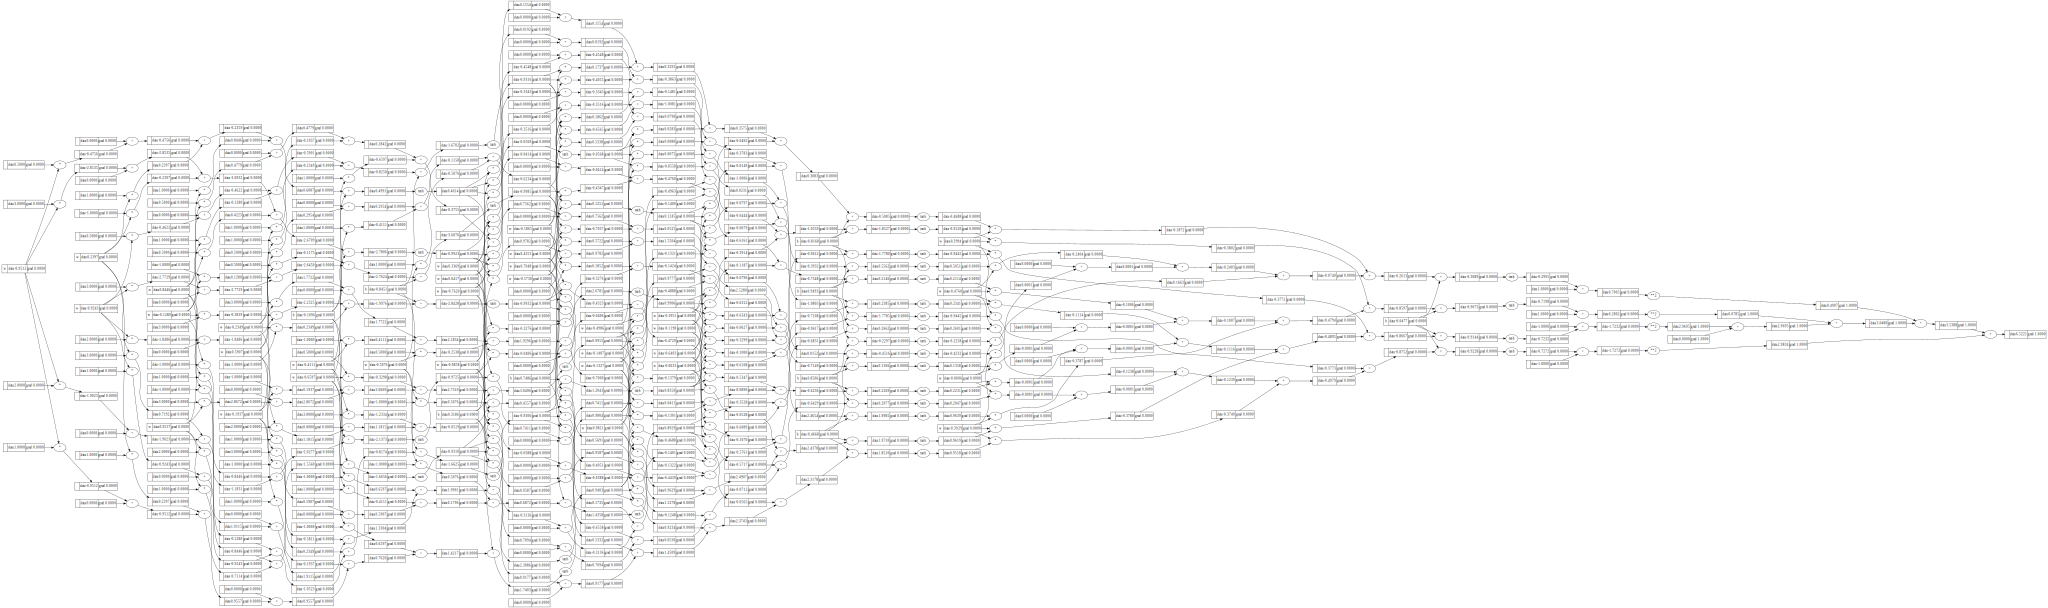

In [122]:
draw_dot(total_loss)

# TODO